# Autoencoder Neural Networks

This section provides examples for implementing autoencoder neural network models. Make sure that you have downloaded and installed the latest release of the `scimlstudio` package before running the code in this section.

Autoencoders is a special type of neural network architecture that is used to project high-dimensional data onto a low-dimensional space, similar to the proper orthogonal decomposition (POD) method introduced in the [previous section](https://computationaldesignlab.github.io/surrogate-methods/pod.html). The difference between POD and autoencoders is that autoencoders use two neural networks to project and reconstruct high-dimensional data. Since neural networks with nonlinear activation functions are used, the projection of the data to the low-dimensional space happens in a nonlinear manner. Due to this, autoencoders can capture nonlinear behavior and trends in the high-dimensional data. This is possible to do using neural networks as they can easily predict an arbritrary number of outputs and use data with an arbritrary input dimensionality. A graphical representation of autoencoder neural networks is shown below.

<div style="text-align:center;">
    <img src="./images/autoencoder.png" width="500" alt="autoencoder diagram">
</div>

The encoder neural network, $f_{\theta}$, projects the high-dimensional data, $\textbf{X} \in \mathbb{R}^n$, to a set of latent variables, $\textbf{z} \in \mathbb{R}^m$, with $m << n$. Here, the term latent variables is used to describe a set of variables that are not directly observable but represent important information about the data. The decoder neural network, $g_{\phi}$, uses the latent variables to reconstruct the high-dimensional data. Here, the subscript indicates the set of parameters that describe the neural network. This operation can be mathematically represented as follows.

$$\hat{\textbf{X}} = g_{\phi}(f_{\theta}(\textbf{X}))$$

The above mathematical relation indicates that the autoencoder is trying to approximate the identity function where the output of the autoencoder neural network is the same as the input. This is enforced using the loss function during the training process of the autoencoder. Enforcing the autoencoder to learn the identity function ensures that the set of latent variables capture features that are most important for representing the data. The latent variables can then be used as a representation of the high-dimensional data in downstream modeling tasks. The autoencoder neural network is trained by minimizing the mean squared error loss function to obtain the best parameters, $\psi^* = \{ \theta^*, \phi^* \}$, for the autoencoder according to the data provided to the model. This optimization problem can be written as

$$
\begin{equation}
      \pmb{\psi}^* = \min_{\pmb{\psi}} \mathcal{L}(\pmb{\psi}) = \min_{\pmb{\psi}} \frac{1}{N} \sum_{i=1}^{N} \Big \lVert \mathbf{X}^{(i)} - g_{\phi}(f_{\theta}(\mathbf{X}^{(i)})) \Big \rVert^2_2.
\end{equation}
$$

Similar to other neural networks, autoencoder models can be trained by solving the above optimization problem using a gradient descent algorithm or the ADAM algorithm with gradients calculated using backpropagation. As with all neural networks, the choice of hyperparameters for the autoencoder significantly impacts the performance of the autoencoder. To learn more about autoencoders and their application to surrogate modeling, you can also look at the following resources:

[1] [Hinton, Geoffrey E., and Ruslan R. Salakhutdinov. "Reducing the dimensionality of data with neural networks." science 313.5786 (2006): 504-507.](https://www.science.org/doi/10.1126/science.1127647)

[2] [Halder, Rakesh, Krzysztof J. Fidkowski, and Kevin J. Maki. "Non‐intrusive reduced‐order modeling using convolutional autoencoders." International Journal for Numerical Methods in Engineering 123.21 (2022): 5369-5390.](https://onlinelibrary.wiley.com/doi/full/10.1002/nme.7072)

[3] [What is an Autoencoder? IBM blog post.](https://www.ibm.com/think/topics/autoencoder)

The first block of code imports the packages required for this section of the Jupyter book.

> __*NOTE*__: You may see some warnings when running the code in this section. These can be safely ignored. 

In [1]:
import torch
from scimlstudio.models import FeedForwardAutoencoder, POD
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
from pyDOE3 import lhs
from scimlstudio.utils import Standardize, Normalize
from scimlstudio.utils import evaluate_vector

# defining the device and data types
args = {"device": torch.device('cuda' if torch.cuda.is_available() else 'cpu'), "dtype": torch.float32}

/Users/gallifrey/miniconda3/envs/surrogate_methods_sp26/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Environment Model Function

The use of autoencoder neural networks will be demonstrated using the [Environment Model Function (EMF)](https://www.sfu.ca/~ssurjano/environ.html) that can be described as follows:

$$h(s,t|\textbf{x})= \frac{M}{\sqrt{4\pi Dt}}\text{exp}(\frac{-s^2}{4Dt}) + \frac{1_{t>\tau}M}{\sqrt{4\pi D(t-\tau)}}\text{exp}(\frac{-(s-L)^2}{4D(t-\tau)}).$$

This is the same function that was used in the [previous section](https://computationaldesignlab.github.io/surrogate-methods/pod.html) to demonstrate the POD method. More details about the function and contour plots of the function can be found in the previous section. The following block of code defines the EMF. The EMF is evaluated on a 32 x 32 grid for $(s,t)$ which means that there are a total of 1024 values to model for the EMF over this grid. It is challenging to predict this function because the indicator function in the numerator of the second term introduces a discontinuity within the function. After constructing the autoencoder neural network, we will compare the results obtained from the autoencoder neural networks with the results from POD.

In [2]:
# defining the grid for the function
s_grid = torch.linspace(0.0, 2.50, 32, **args)
t_grid = torch.linspace(15.0, 60.0, 32, **args)
Sgrid, Tgrid = torch.meshgrid(s_grid, t_grid)

def env_model_function(x: torch.Tensor) -> torch.Tensor:
    """
        Parameters
        ----------
        x: torch.Tensor
            2D tensor array with the inputs to the function

        Returns
        -------
        y: torch.Tensor
            Values of the EMF evaluated for the given inputs

    """

    # extracting values of variables
    M = x[0]
    D = x[1]
    L = x[2]
    tau = x[3]

    first_term = (M/torch.sqrt(4 * torch.pi * D * Tgrid)) * torch.exp(-(Sgrid**2)/(4*D*Tgrid))
    second_term = (M/torch.sqrt(4 * torch.pi * D * (Tgrid - tau))) * torch.exp(-((Sgrid - L) ** 2)/(4*D*(Tgrid - tau)))
    second_term[torch.isnan(second_term)] = 0.0
    y = first_term + second_term

    return y

/Users/gallifrey/miniconda3/envs/surrogate_methods_sp26/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4319.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Now, we will create some training and testing data for the autoencoder neural networks. 1000 training samples and 50 testing samples will be generated. Latin hypercube sampling (LHS) is used to generate the training and testing data for the autoencoder neural networks. 

In [3]:
# defining the bounds
l_bounds = torch.tensor([7.0, 0.02, 0.01, 30.01], **args)
u_bounds = torch.tensor([13.0, 0.12, 3.0, 30.295], **args)

# training data generation
train_samples = torch.tensor(lhs(n=4, samples=1000, criterion='cm', iterations=100), **args)
train_samples = l_bounds + (u_bounds - l_bounds) * train_samples
xtrain = torch.stack([env_model_function(x) for x in train_samples]) # this uses a 32x32 grid leading to a total of 1024 outputs
print(f"Shape of training data: {xtrain.shape}")

# testing data generation
test_samples = torch.tensor(lhs(n=4, samples=50, criterion='cm', iterations=100), **args)
test_samples = l_bounds + (u_bounds - l_bounds) * test_samples
xtest = torch.stack([env_model_function(x) for x in test_samples])
print(f"Shape of testing data: {xtest.shape}")

Shape of training data: torch.Size([1000, 32, 32])
Shape of testing data: torch.Size([50, 32, 32])


## Constructing the autoencoder neural network

The `FeedForwardAutoencoder` class from `scimlstudio` will be used to create autoencoder neural networks. This class has the following four required inputs:
- `x_train`: Data matrix for the autoencoder neural network. This must have dimensions $m \times n$, where $m$ is the number of samples in the matrix and $n$ is the number of outputs for the grid.
- `encoder`: `torch.nn.Sequential` object that defines the encoder network for the autoencoder.
- `decoder`: `torch.nn.Sequential` object that defines the decoder network for the autoencoder. In most cases, the architecture of the decoder is a mirror image of the encoder architecture. This leads to a symmetric autoencoder. However, you can also have an asymmetric autoencoder where the decoder architecture is not a mirror image of the encoder architecture.
- `data_transform`: `Standardize` or `Normalize` transform object from `scimlstudio` for the data matrix. Standardizing the data matrix often leads to better results and therefore, standardization is used here. It is important to note that the matrix provided to the transform class must have dimensions $m \times n$. 

The following block of code builds the autoencoder model using standardization as the data transform. The network is initialized using the glorot normal initialization. 

In [4]:
# utility function from neural networks section of book for initializing the weights of the netwo
def init_weights(m):
    """
        Function for initializing the weights using glorot (or xavier) normal initialization
    """

    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_normal_(m.weight) # change this for other init methods
        m.bias.data.fill_(0.0)

# defining the encoder
encoder = torch.nn.Sequential(
    torch.nn.Linear(xtrain.flatten(1).shape[-1], 256),
    torch.nn.SiLU(),
    torch.nn.Linear(256, 64),
    torch.nn.SiLU(),
    torch.nn.Linear(64, 16)
).to(**args)

# defining the decoder
decoder = torch.nn.Sequential(
    torch.nn.Linear(16, 64),
    torch.nn.SiLU(),
    torch.nn.Linear(64, 256),
    torch.nn.SiLU(),
    torch.nn.Linear(256, xtrain.flatten(1).shape[-1]),
    torch.nn.Sigmoid()
).to(**args)

# initializing the networks
encoder.apply(init_weights)
decoder.apply(init_weights)

# defining the data transform
data_transform = Normalize(xtrain.flatten(1))

# defining the autoencoder
autoencoder = FeedForwardAutoencoder(x_train=xtrain.flatten(1), encoder=encoder, decoder=decoder, data_transform=data_transform)

## Training the autoencoder neural networks

The autoencoder neural network created in the previous code block can be trained using the `fit` method from the `FeedForwardAutoencoder` class object. The `fit` method is identical to the `fit` method of the `FeedForwardNeuralNetwork` class described in the [neural network section](https://computationaldesignlab.github.io/surrogate-methods/nn_models.html) of this book. This is because autoencoders are a special neural network architecture but they are trained using the same method as all other neural networks. Refer to the [neural networks section](https://computationaldesignlab.github.io/surrogate-methods/nn_models.html) for more details of the `fit` method. 

Here, the autoencoders are trained using the ADAM optimizer with a learning rate of 1e-3 for 5000 epochs with a batch size equal to the number of samples in the training data. The following block of code trains the autoencoder neural networks on the training data generated earlier. 

In [5]:
optimizer = torch.optim.Adam(autoencoder.parameters, lr=1e-3)
loss_func = torch.nn.MSELoss() 

# training the autoencoder
autoencoder.fit(optimizer=optimizer, loss_func=loss_func, batch_size=xtrain.shape[0], epochs=5000)

## Reconstructing the EMF using the autoencoder network

Once the autoencoder has been trained, it can be used to project the high-dimensional EMF data to a low-dimensional latent space. The low-dimensional latent space can then be used to reconstruct the original high-dimensional data. The projection to the latent space can be done using the `encoding` method of the `FeedForwardAutoencoder` class and the reconstruction from the latent space can be done using the `decoding` method of the `FeedForwardAutoencoder` class. This is demonstrated in the following code block:

In [6]:
# Projecting EMF data to the latent space
z = autoencoder.encoding(xtrain.flatten(1))
print("Shape of projection:", z.shape)
# Reconstructing the EMF data from the latent space
X = autoencoder.decoding(z)
print("Shape of reconstruction:", X.shape)

Shape of projection: torch.Size([1000, 16])
Shape of reconstruction: torch.Size([1000, 1024])


The above computations show that the original 1024 outputs can actually be compressed to a representation with only 16 outputs using autoencoders.

> __*NOTE*__: In POD, the dimensionality of the low-dimensional space was automatically chosen using the relative information criterion (RIC). However, the dimensionality of the low-dimensional space is a hyperparameter in the autoencoder model and must be chosen carefully to ensure best prediction accuracy. 

As noted in the [POD section](https://computationaldesignlab.github.io/surrogate-methods/pod.html), chaining together the process of projection and reconstruction creates a surrogate model that will reconstruct the input. Similar to the `POD` class, the `predict` method from the `FeedForwardAutoencoder` can be used to predict the reconstruction of a given high-dimensional input. This is demonstrated using the testing data generated earlier and the predictions are visualized. The absolute error between the predictions and the ground truth is also visualized to illustrate the distribution of error in the reconstruction of the autoencoder model. Similar to POD model errors, the error of the autoencoder is concentrated near $t=30s$ where the discontinuity in the EMF occurs.

In [7]:
# using the predict method to reconstruct the EMF
predictions = autoencoder.predict(xtest.flatten(1))
predictions_reshaped = predictions.reshape([xtest.shape[0],32,32])

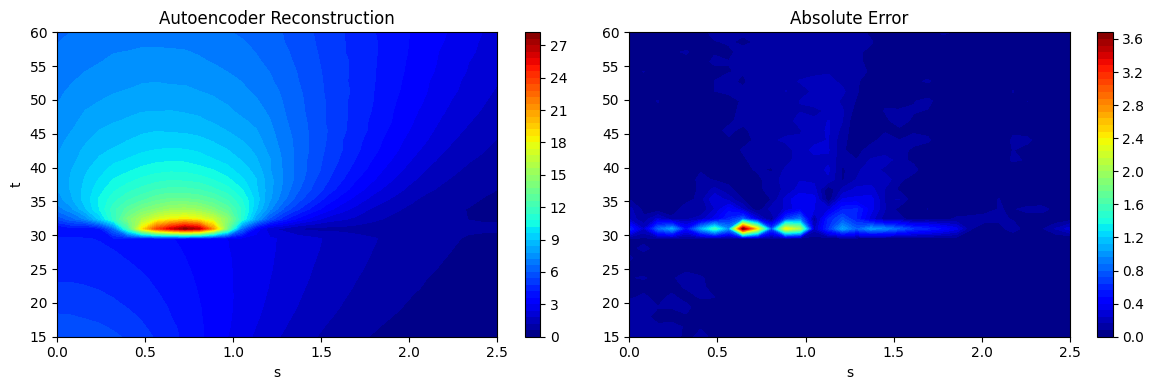

In [8]:
# plotting the reconstructions
fig, ax = plt.subplots(1,2, figsize=(12,4))

contour = ax[0].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), predictions_reshaped[15].numpy(force=True), 
                         levels = 50, cmap='jet')
ax[0].set_xlabel("s") 
ax[0].set_ylabel("t") 
ax[0].set_title("Autoencoder Reconstruction")
fig.colorbar(contour, ax=ax[0])

contour = ax[1].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), abs(xtest[15] - predictions_reshaped[15]).numpy(force=True), 
                         levels = 50, cmap='jet')
ax[1].set_xlabel("s") 
ax[1].set_title("Absolute Error")
fig.colorbar(contour, ax=ax[1])

plt.tight_layout()

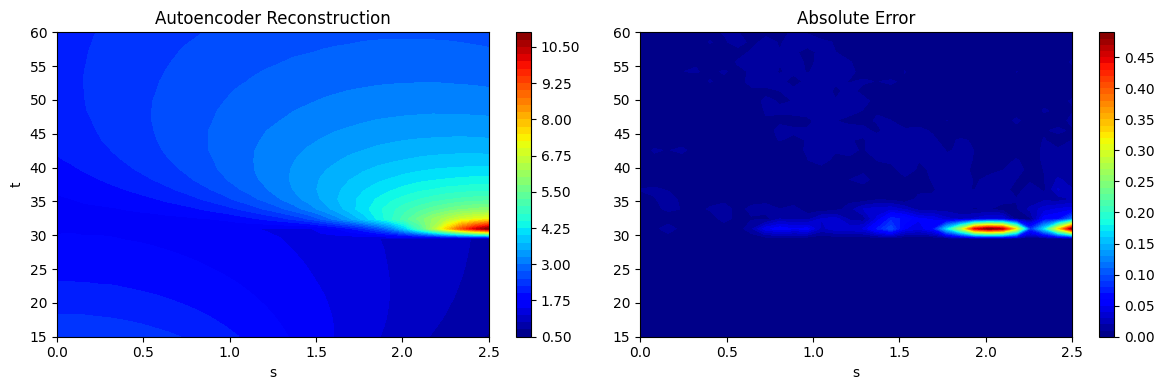

In [9]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

contour = ax[0].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), predictions_reshaped[20].numpy(force=True), levels = 50, cmap='jet')
ax[0].set_xlabel("s") 
ax[0].set_ylabel("t") 
ax[0].set_title("Autoencoder Reconstruction")
fig.colorbar(contour, ax=ax[0])

contour = ax[1].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), abs(xtest[20] - predictions_reshaped[20]).numpy(force=True), levels = 50, cmap='jet')
ax[1].set_xlabel("s") 
ax[1].set_title("Absolute Error")
fig.colorbar(contour, ax=ax[1])

plt.tight_layout()

## NRMSE Calculation and Comparison with POD

We calculate the NRMSE for each grid point as an error metric to evaluate the overall accuracy of the autoencoder model. We plot the countours of the NRMSE to illustrate how the error is distributed over the 2D grid of the EMF. We also create a POD model for the EMF in an identical manner to [POD section](https://computationaldesignlab.github.io/surrogate-methods/pod.html) of the book to compare the POD method with the autoencoder method. 

The next block of code defines the POD model for the EMF function using the same procedure as outline in the [POD section](https://computationaldesignlab.github.io/surrogate-methods/pod.html) of the book.

In [10]:
# defining the POD model and fitting it to the training data
transform = Standardize(xtrain.flatten(1))
pod = POD(s_train=xtrain.flatten(1).mT, ric=0.9999, snapshot_transform=transform)
pod.fit()
print(f"Number of modes to meet RIC value: {pod.k}")

# generating predictions on testing data using the POD model
predictions_pod = pod.predict(xtest.flatten(1).mT)
predictions_pod_reshaped = predictions.mT.reshape([xtest.shape[0],32,32])

Number of modes to meet RIC value: 20


The next block of code calculates the NRMSE for the POD and autoencoder models using the `evaluate_vector` function from `scimlstudio` and plots the NRMSE contours. For both models, the main difficulty in prediction still arises due to the discontinuity near the $t=30s$ region of the contour plot. Majority of the error is concentrated in this region of the plot. Since the autoencoder model is a neural network model, it generally works better when there is availability of a larger amount of data. For the EMF, both the autoencoder and POD model achieve less than 1% average NRMSE with enough number of training samples. In the case of the autoencoder, the hyperparameters play a large role in the prediction accuracy of the model and choosing these carefully can lead to a further boost in accuracy.  

Average value of NRMSE of autoencoder across grid: 0.004515938926488161
Average value of NRMSE of POD across grid: 0.0027282414957880974


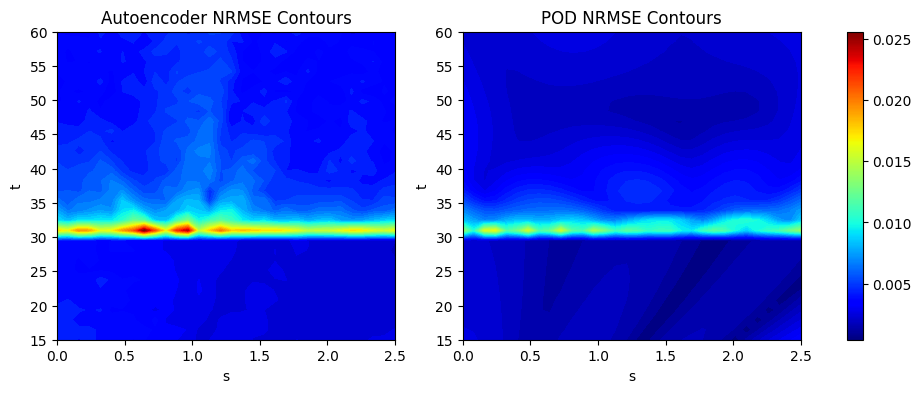

In [11]:
import numpy as np

# calculating the nrmse for each grid point
nrmse_autoencoder = evaluate_vector(true_values=xtest.flatten(1), predict_values=predictions, metric="nrmse").reshape(32,32).numpy(force=True)
print(f"Average value of NRMSE of autoencoder across grid: {np.mean(nrmse_autoencoder)}")

nrmse_pod = evaluate_vector(true_values=xtest.flatten(1), predict_values=predictions_pod.mT, metric="nrmse").reshape(32,32).numpy(force=True)
print(f"Average value of NRMSE of POD across grid: {np.mean(nrmse_pod)}")

# generating the min and max of the NRMSE contours
vmin = np.min([nrmse_autoencoder.min(), nrmse_pod.min()])
vmax = np.max([nrmse_autoencoder.max(), nrmse_pod.max()])

# plotting the nrmse contours for both models
fig, ax = plt.subplots(1,2, figsize=(12,4))
contour1 = ax[0].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), nrmse_autoencoder, levels = 50, cmap='jet', vmin=vmin, vmax=vmax)
ax[0].set_xlabel("s") 
ax[0].set_ylabel("t") 
ax[0].set_title("Autoencoder NRMSE Contours")

contour2 = ax[1].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), nrmse_pod, levels = 50, cmap='jet', vmin=vmin, vmax=vmax)
ax[1].set_xlabel("s") 
ax[1].set_ylabel("t") 
ax[1].set_title("POD NRMSE Contours")

# normalzing the colorbar across both subplots
norm = colors.Normalize(vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(cmap='jet', norm=norm)
fig.colorbar(sm, ax=ax)